## PCA

#### Task 1: Exploratory Data Analysis (EDA):

##### 1.	Load the dataset and perform basic data exploration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\Rakshitha\Downloads\wine.csv")

# Display first 5 rows
print(df.head())

# Shape of dataset
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns)

# Data types
print(df.dtypes)

# Dataset info
df.info()

# Statistical summary
print(df.describe())

# Check missing values
print(df.isnull().sum())

   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  
Shape: (178, 14)
Columns: Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'N

##### 2.	Examine the distribution of features using histograms, box plots, or density plots.

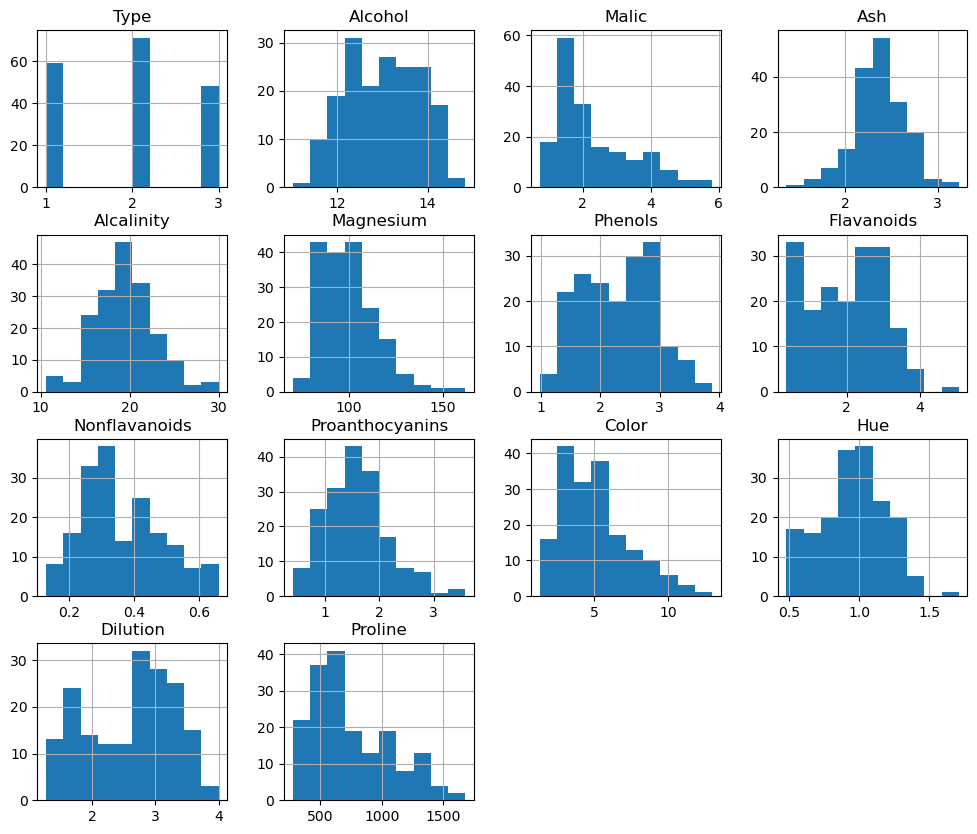

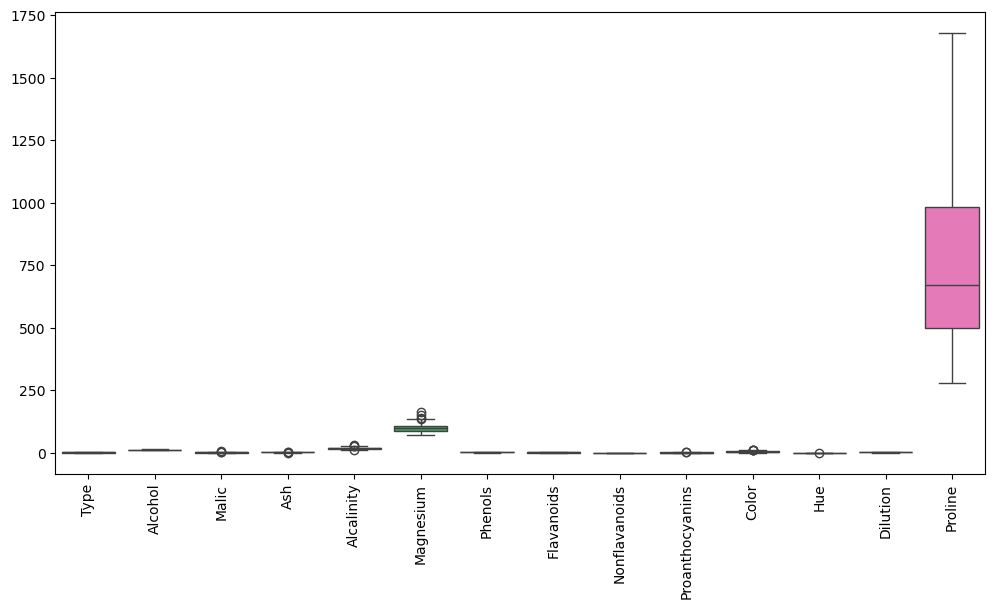

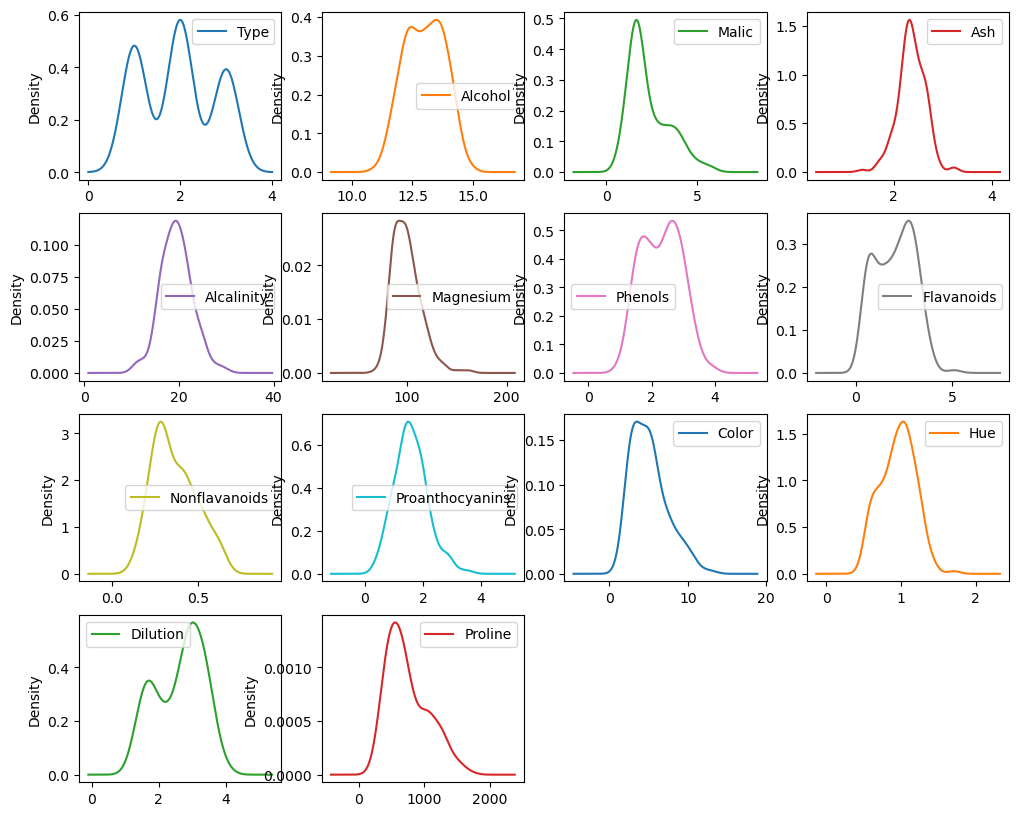

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Histograms ----------------
df.hist(figsize=(12,10))
plt.show()

# ---------------- Box Plots ----------------
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# ---------------- Density Plots ----------------
df.plot(kind='density', subplots=True, layout=(4,4), figsize=(12,10), sharex=False)
plt.show()

##### 3.	Investigate correlations between features to understand relationships within the data.

                     Type   Alcohol     Malic       Ash  Alcalinity  \
Type             1.000000 -0.328222  0.437776 -0.049643    0.517859   
Alcohol         -0.328222  1.000000  0.094397  0.211545   -0.310235   
Malic            0.437776  0.094397  1.000000  0.164045    0.288500   
Ash             -0.049643  0.211545  0.164045  1.000000    0.443367   
Alcalinity       0.517859 -0.310235  0.288500  0.443367    1.000000   
Magnesium       -0.209179  0.270798 -0.054575  0.286587   -0.083333   
Phenols         -0.719163  0.289101 -0.335167  0.128980   -0.321113   
Flavanoids      -0.847498  0.236815 -0.411007  0.115077   -0.351370   
Nonflavanoids    0.489109 -0.155929  0.292977  0.186230    0.361922   
Proanthocyanins -0.499130  0.136698 -0.220746  0.009652   -0.197327   
Color            0.265668  0.546364  0.248985  0.258887    0.018732   
Hue             -0.617369 -0.071747 -0.561296 -0.074667   -0.273955   
Dilution        -0.788230  0.072343 -0.368710  0.003911   -0.276769   
Prolin

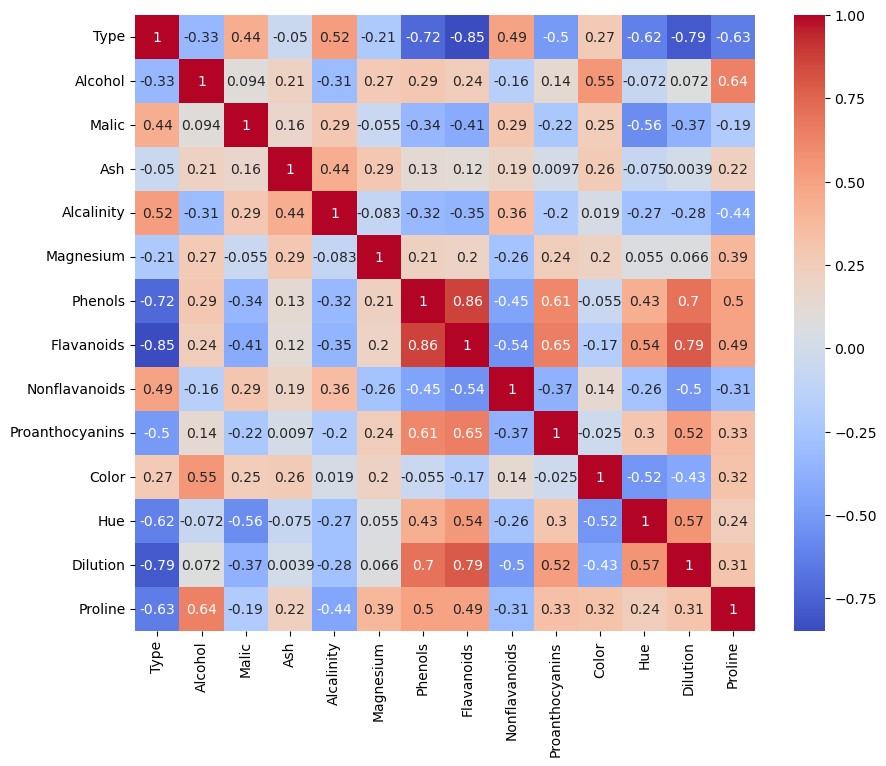

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr_matrix = df.corr()

# Display correlation values
print(corr_matrix)

# Visualize correlation matrix using heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

#### Task 2: Dimensionality Reduction with PCA:

##### 1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Separate features (drop target column if present)
X = df.drop(columns=['target'], errors='ignore')

# -------- Standardization --------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------- PCA --------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Results
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Shape after PCA:", X_pca.shape)

Explained Variance Ratio: [0.39542486 0.17836259]
Shape after PCA: (178, 2)


##### 2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.

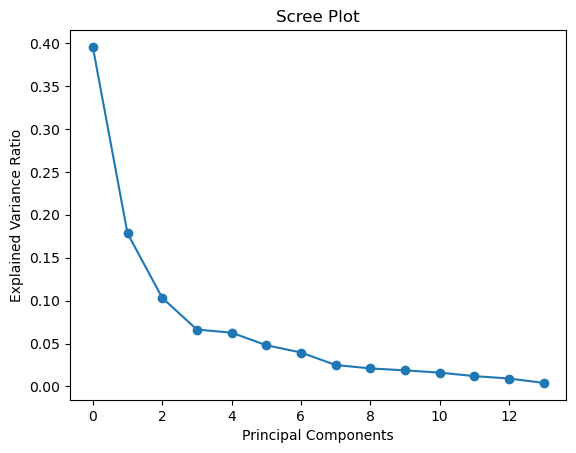

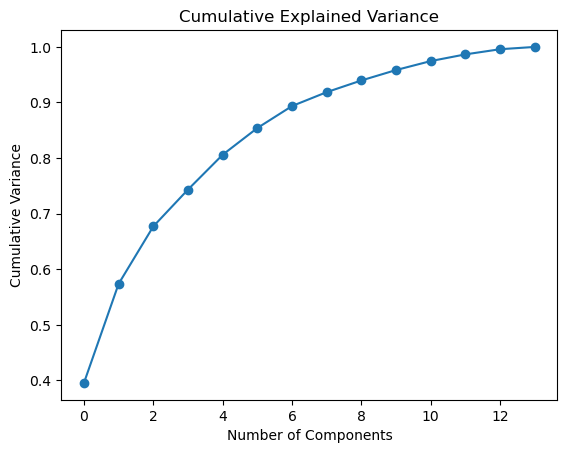

[0.39542486 0.57378745 0.67707846 0.74335831 0.80603706 0.85409266
 0.89364973 0.91865217 0.93969088 0.95842703 0.97455906 0.98661596
 0.99587055 1.        ]


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Features
X = df.drop(columns=['target'], errors='ignore')

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (all components)
pca = PCA()
pca.fit(X_scaled)

# -------- Scree Plot --------
plt.figure()
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.show()

# -------- Cumulative Explained Variance --------
cum_var = pca.explained_variance_ratio_.cumsum()

plt.figure()
plt.plot(cum_var, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()

# Print cumulative variance
print(cum_var)

##### 3.	Transform the original dataset into the principal components.

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Separate features
X = df.drop(columns=['target'], errors='ignore')

# -------- Standardization --------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------- PCA Transformation --------
pca = PCA(n_components=2)   # use optimal number if already determined
X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Display transformed data
print(pca_df.head())

        PC1       PC2
0 -3.522934  1.453098
1 -2.528858 -0.330019
2 -2.785029  1.036936
3 -3.922588  2.768210
4 -1.407511  0.867773


#### Task 3: Clustering with Original Data:

##### 1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.

In [10]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Separate features (drop target column if present)
X = df.drop(columns=['target'], errors='ignore')

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Display result
print(df.head())

   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  Cluster  
0           0.28             2.29   5.64  1.04      3.92     1065        2  
1           0.26             1.28   4.38  1.05      3.40     1050        2  
2           0.30             2.81   5.68  1.03      3.17     1185        2  
3           0.24             2.18   7.80  0.86      3.45     1480        2  
4           0.39             1.82   4.32  1.04      2.93      735        2  


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


##### 2.	Visualize the clustering results using appropriate plots.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


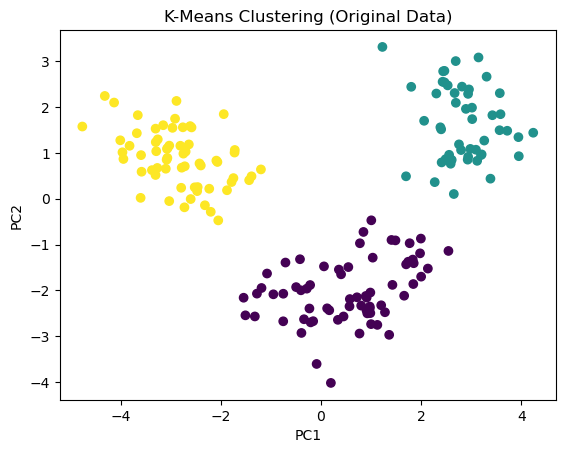

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Features
X = df.drop(columns=['target'], errors='ignore')

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering (Original Data)")
plt.show()

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Features
X = df.drop(columns=['target'], errors='ignore')

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# -------- Evaluation --------
sil_score = silhouette_score(X_scaled, clusters)
db_index = davies_bouldin_score(X_scaled, clusters)

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_index)

Silhouette Score: 0.3493563848593293
Davies-Bouldin Index: 1.1843074626362828


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


#### Task 4: Clustering with PCA Data:

##### 1.	Apply the same clustering algorithm to the PCA-transformed dataset.

In [13]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Features
X = df.drop(columns=['target'], errors='ignore')

# -------- Standardization --------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------- PCA Transformation --------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------- K-Means Clustering --------
kmeans = KMeans(n_clusters=3, random_state=42)
df['PCA_Cluster'] = kmeans.fit_predict(X_pca)

# Display result
print(df.head())

   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  Cluster  \
0           0.28             2.29   5.64  1.04      3.92     1065        2   
1           0.26             1.28   4.38  1.05      3.40     1050        2   
2           0.30             2.81   5.68  1.03      3.17     1185        2   
3           0.24             2.18   7.80  0.86      3.45     1480        2   
4           0.39             1.82   4.32  1.04      2.93      735        2   

   PCA_Cluster  
0            2  
1            2  
2            2  


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


##### 2.	Visualize the clustering results obtained from PCA-transformed data.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


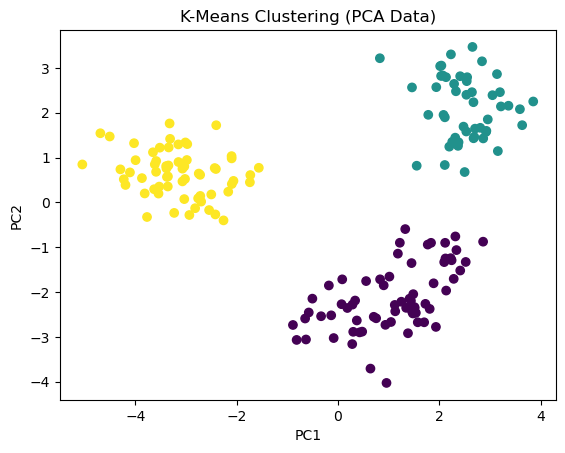

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Features
X = df.drop(columns=['target'], errors='ignore')

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Plot clusters
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering (PCA Data)")
plt.show()

##### 3.	Compare the clustering results from PCA-transformed data with those from the original dataset.

In [16]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Features
X = df.drop(columns=['target'], errors='ignore')

# -------- Standardization --------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------- K-Means on Original Data --------
kmeans_orig = KMeans(n_clusters=3, random_state=42)
clusters_orig = kmeans_orig.fit_predict(X_scaled)

sil_orig = silhouette_score(X_scaled, clusters_orig)
db_orig = davies_bouldin_score(X_scaled, clusters_orig)

# -------- PCA Transformation --------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------- K-Means on PCA Data --------
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

sil_pca = silhouette_score(X_pca, clusters_pca)
db_pca = davies_bouldin_score(X_pca, clusters_pca)

# -------- Comparison --------
print("Original Data:")
print("Silhouette Score:", sil_orig)
print("Davies-Bouldin Index:", db_orig)

print("\nPCA Data:")
print("Silhouette Score:", sil_pca)
print("Davies-Bouldin Index:", db_pca)

Original Data:
Silhouette Score: 0.38109305610041566
Davies-Bouldin Index: 1.1127458886842676

PCA Data:
Silhouette Score: 0.7162148693666409
Davies-Bouldin Index: 0.4025662382041162


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


#### Task 5: Comparison and Analysis:

##### 1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.

In [17]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Features
X = df.drop(columns=['target'], errors='ignore')

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----- Original Data Clustering -----
kmeans1 = KMeans(n_clusters=3, random_state=42)
labels1 = kmeans1.fit_predict(X_scaled)

sil1 = silhouette_score(X_scaled, labels1)
db1 = davies_bouldin_score(X_scaled, labels1)

# ----- PCA Data Clustering -----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans2 = KMeans(n_clusters=3, random_state=42)
labels2 = kmeans2.fit_predict(X_pca)

sil2 = silhouette_score(X_pca, labels2)
db2 = davies_bouldin_score(X_pca, labels2)

# ----- Comparison -----
print("Original Data -> Silhouette:", sil1, "| DB Index:", db1)
print("PCA Data      -> Silhouette:", sil2, "| DB Index:", db2)

# Simple conclusion
if sil2 > sil1 and db2 < db1:
    print("\nPCA-based clustering performs better.")
else:
    print("\nOriginal data clustering performs better or is comparable.")

Original Data -> Silhouette: 0.38109305610041566 | DB Index: 1.1127458886842676
PCA Data      -> Silhouette: 0.7162148693666409 | DB Index: 0.4025662382041162

PCA-based clustering performs better.


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


##### 2.	Discuss any similarities or differences observed in the clustering results.

##### Similarities

Both original data and PCA-transformed data generally identify a similar number of clusters.
    
The overall grouping pattern may remain consistent, meaning some data points belong to the same clusters in both methods.
    
Major structures in the dataset are preserved even after dimensionality reduction.

##### Differences

PCA-based clustering often shows more compact and well-separated clusters due to noise reduction.
    
Original data clustering may capture more detailed patterns but can include noise and redundant features.
    
Cluster boundaries in PCA are usually clearer and easier to visualize in 2D space.
    
Evaluation metrics (Silhouette Score, Davies–Bouldin Index) may differ, indicating changes in clustering quality.
    
Some data points may be assigned to different clusters after PCA due to transformation of features.

##### 3.	Reflect on the impact of dimensionality reduction on clustering performance.

##### Dimensionality reduction using PCA has a significant impact on clustering performance.

PCA reduces the number of features while preserving the most important information in the data. This helps in removing noise and redundant features, which can improve clustering quality.
    
It often leads to better-defined and more compact clusters, making patterns easier to identify.
    
Clustering algorithms like K-Means perform faster on reduced dimensions because of lower computational complexity.
    
Visualization becomes easier (e.g., 2D plots), helping in better interpretation of clusters.

However, there are some limitations:

PCA may result in loss of some information, which can affect clustering accuracy.
    
Important features with lower variance might be ignored, potentially impacting cluster formation.

##### 4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.

##### Advantages of PCA before Clustering

Reduces dimensionality, making computation faster and more efficient.
    
Removes noise and redundant features, which can improve cluster quality.
    
Helps in better visualization (especially in 2D or 3D).
    
Can lead to more compact and well-separated clusters.

In [ ]:
Disadvantages of PCA before Clustering
Causes loss of information, as not all variance is retained.
Principal components are not easily interpretable compared to original features.
Important low-variance features might be ignored.